In [2]:
# CUBIST PART
!pip install cubist -q
print("cubist installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.0/594.0 kB 24.3 MB/s eta 0:00:00
cubist installed.


In [3]:
from cubist import Cubist
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

df = pd.read_csv('/content/Steel_industry_data.csv')
df = df.drop(columns=['date'])

# Convert categoricals to category dtype (Cubist handles them natively)
for col in ['WeekStatus', 'Day_of_week', 'Load_Type']:
    df[col] = df[col].astype('category')

target_col = 'Usage_kWh'
X = df.drop(columns=[target_col])
y = df[target_col]

# Same chronological 80/20 split
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Build CUBIST with parameters approximating Sathishkumar 2020b
cubist = Cubist(
    n_rules=100,
    n_committees=36,
    neighbors=3,
    unbiased=False,
    extrapolation=0.0,
    sample=None,
    random_state=42,
)

print("Training CUBIST …")
cubist.fit(X_train, y_train)
print("Training complete.")

cubist_preds = cubist.predict(X_test)

cubist_mae  = mean_absolute_error(y_test, cubist_preds)
cubist_rmse = np.sqrt(mean_squared_error(y_test, cubist_preds))
cubist_r2   = r2_score(y_test, cubist_preds)

print(f"\nCUBIST Test Results")
print(f"  MAE  = {cubist_mae:.4f} kWh")
print(f"  RMSE = {cubist_rmse:.4f} kWh")
print(f"  R²   = {cubist_r2:.4f}")
errors = np.abs(y_test.values - cubist_preds)
print(f"Median error : {np.median(errors):.4f}")
print(f"95th pct err : {np.percentile(errors, 95):.4f}")
print(f"99th pct err : {np.percentile(errors, 99):.4f}")
print(f"Max error    : {errors.max():.4f}")
print(f"# errors > 10: {(errors > 10).sum()}")

Train: (28032, 9), Test: (7008, 9)
Training CUBIST …
Training complete.

CUBIST Test Results
  MAE  = 0.1120 kWh
  RMSE = 0.3619 kWh
  R²   = 0.9999
Median error : 0.0224
95th pct err : 0.4839
99th pct err : 1.7603
Max error    : 6.6861
# errors > 10: 0


In [4]:
# Build aligned results dataframe for CUBIST
df_raw = pd.read_csv('/content/Steel_industry_data.csv')
n_total   = len(df_raw)
train_end = int(n_total * 0.80)
test_meta = df_raw.iloc[train_end:].reset_index(drop=True)

# CUBIST predicts on the FULL test set (no windowing).
# Align it to the same rows as the MLP/TCN by skipping the first WINDOW-1 rows.
W = 24
results_cubist = pd.DataFrame({
    'actual':      y_test[W-1:],
    'CUBIST':      cubist_preds[W-1:],
    'Load_Type':   test_meta['Load_Type'].values[W-1:],
    'Day_of_week': test_meta['Day_of_week'].values[W-1:],
})
results_cubist['hour'] = pd.to_datetime(
    test_meta['date'].values[W-1:], format='%d/%m/%Y %H:%M'
).hour
results_cubist['CUBIST_error'] = results_cubist['CUBIST'] - results_cubist['actual']

print(f"CUBIST aligned results: {len(results_cubist)} rows")

# Save for cross-reference with VS Code outputs
results_cubist.to_csv('cubist_test_predictions.csv', index=False)
print("Saved to cubist_test_predictions.csv")

CUBIST aligned results: 6985 rows
Saved to cubist_test_predictions.csv


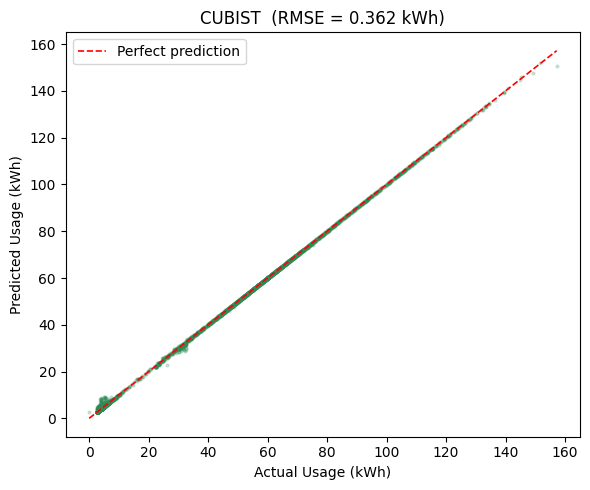

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 5))
lims = [results_cubist['actual'].min(), results_cubist['actual'].max()]

ax.scatter(results_cubist['actual'], results_cubist['CUBIST'],
           alpha=0.2, s=4, color='seagreen')
ax.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect prediction')
rmse = np.sqrt(np.mean(results_cubist['CUBIST_error']**2))
ax.set_title(f'CUBIST  (RMSE = {rmse:.3f} kWh)')
ax.set_xlabel('Actual Usage (kWh)')
ax.set_ylabel('Predicted Usage (kWh)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

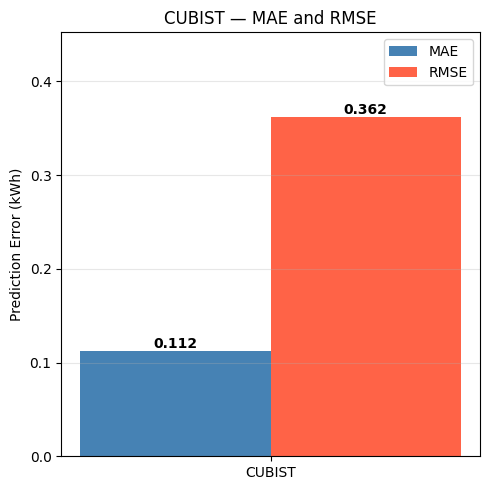

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(5, 5))

x = np.arange(1)              # one group: CUBIST
width = 0.35

mae_bar  = ax.bar(x - width/2, [cubist_mae],  width, label='MAE',  color='steelblue')
rmse_bar = ax.bar(x + width/2, [cubist_rmse], width, label='RMSE', color='tomato')

# Value labels on top of each bar
for bar in list(mae_bar) + list(rmse_bar):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h,
            f'{h:.3f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_ylabel('Prediction Error (kWh)')
ax.set_title('CUBIST — MAE and RMSE')
ax.set_xticks(x)
ax.set_xticklabels(['CUBIST'])
ax.legend(loc='upper right')
ax.set_ylim(0, max(cubist_mae, cubist_rmse) * 1.25)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()